# **LSTM MODEL**


Mount Drive and Data




In [1]:
from google.colab import drive
import os# Mount drive
drive.mount('/content/drive')

# Set dataset path
DATASET_ROOT = "/content/drive/MyDrive/DrivingRiskProject/DrivingRiskDataset/dataset"

# Debug
print(os.listdir(DATASET_ROOT))

Mounted at /content/drive
['5 star', '4 star', '3 star', '2 star', '1 star', 'testing']


Configuration & Model Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Settings
WINDOW_SIZE = 120
STEP_SIZE = 20
SENSOR_COLS = ['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']
RESULTS_DIR = "/content/drive/MyDrive/DrivingRiskProject/results"
MODEL_SAVE = "/content/drive/MyDrive/DrivingRiskProject/lstm_driving_model.h5"
os.makedirs(RESULTS_DIR, exist_ok=True)


def load_dataset(root):
    all_dfs = []

    for star in range(1, 6):
        folder = Path(root) / f"{star} star"
        csv_files = list(folder.glob("*.csv"))
        print(f"  Processing {star}★ — {len(csv_files)} files")

        for fpath in csv_files:
            df = pd.read_csv(fpath)

            if all(col in df.columns for col in SENSOR_COLS):
                df['star_label'] = star
                df['source_file'] = fpath.name
                all_dfs.append(df[SENSOR_COLS + ['star_label', 'source_file']])

    return pd.concat(all_dfs, ignore_index=True)
def make_windows(df):
    X_list, y_list = [], []

    for fname, group in df.groupby('source_file'):
        label = int(group['star_label'].iloc[0]) - 1
        values = group[SENSOR_COLS].values.astype(np.float32)

        for start in range(0, len(values) - WINDOW_SIZE + 1, STEP_SIZE):
            X_list.append(values[start : start + WINDOW_SIZE])
            y_list.append(label)

    X = np.array(X_list)
    y = np.array(y_list)

    # Print dataset shape
    print(f"Final dataset shape: {X.shape}")

    return X, y

def build_model():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(WINDOW_SIZE, 6)),
        Dropout(0.3),
        BatchNormalization(),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

Training the Model

In [3]:
print("[1] Loading Data...")
df_raw = load_dataset(DATASET_ROOT)

X, y = make_windows(df_raw)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Print shapes
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# Scale
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 6))

X_train_n = scaler.transform(X_train.reshape(-1, 6)).reshape(len(X_train), WINDOW_SIZE, 6)
X_test_n = scaler.transform(X_test.reshape(-1, 6)).reshape(len(X_test), WINDOW_SIZE, 6)
# Train
model = build_model()
callbacks = [EarlyStopping(patience=8, restore_best_weights=True),
             ModelCheckpoint(MODEL_SAVE, save_best_only=True)]

print("[2] Training Starting...")
history = model.fit(X_train_n, to_categorical(y_train, 5),
                    validation_split=0.15, epochs=50, batch_size=64, callbacks=callbacks)

# Save Scaler
with open(f"{RESULTS_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print(" Training Complete!")

[1] Loading Data...
  Processing 1★ — 32 files
  Processing 2★ — 36 files
  Processing 3★ — 50 files
  Processing 4★ — 48 files
  Processing 5★ — 29 files
Final dataset shape: (150496, 120, 6)
Train shape: (120396, 120, 6)
Test shape: (30100, 120, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 120, 256)       │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,197 (1.19 MB)

...

1599/1599 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.9014 - loss: 0.2314 - val_accuracy: 0.8968 - val_loss: 0.2418
Epoch 45/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.9027 - loss: 0.2290 - val_accuracy: 0.8785 - val_loss: 0.3240
Epoch 46/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9013 - loss: 0.2294

1599/1599 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.9012 - loss: 0.2304 - val_accuracy: 0.8987 - val_loss: 0.2416
Epoch 47/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9034 - loss: 0.2250

1599/1599 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.9033 - loss: 0.2261 - val_accuracy: 0.8986 - val_loss: 0.2412
Epoch 48/50
1598/1599 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9033 - loss: 0.2254

1599/1599 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.9025 - loss: 0.2278 - val_accuracy: 0.8954 - val_loss: 0.2402
Epoch 49/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9036 - loss: 0.2231

1599/1599 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.9038 - loss: 0.2234 - val_accuracy: 0.9011 - val_loss: 0.2352
Epoch 50/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.9036 - loss: 0.2259 - val_accuracy: 0.8965 - val_loss: 0.2483
 Training Complete!


Metrics, Visualizations



DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

1★ Dangerous       0.83      0.92      0.87      6561
     2★ Poor       0.98      0.93      0.95      4978
  3★ Average       0.97      0.89      0.93      7005
     4★ Good       0.91      0.91      0.91      7697
     5★ Safe       0.83      0.84      0.84      3859

    accuracy                           0.90     30100
   macro avg       0.90      0.90      0.90     30100
weighted avg       0.91      0.90      0.90     30100



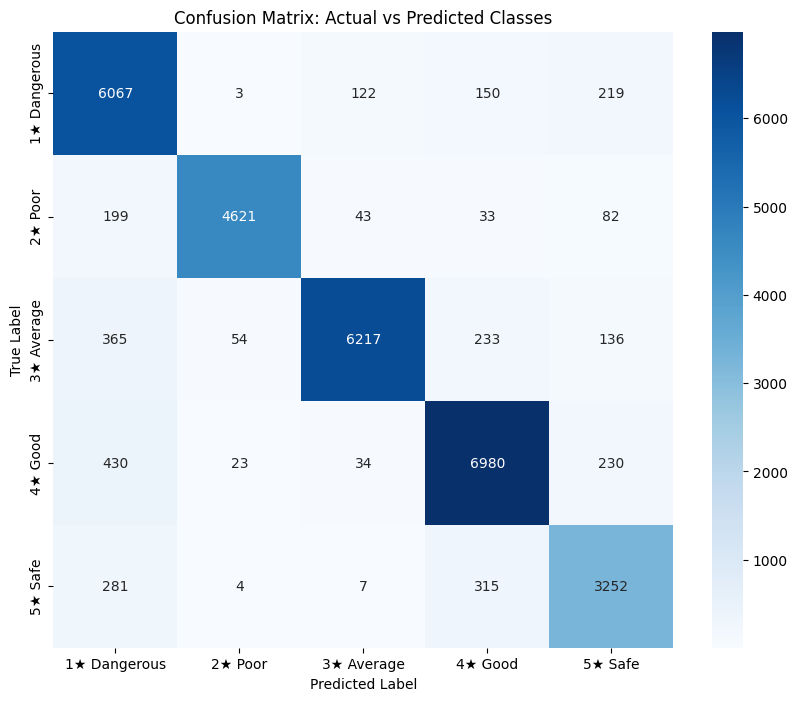

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

def show_detailed_metrics(model, X_test_n, y_test):
    # 1. Get Predictions
    y_probs = model.predict(X_test_n, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)

    # 2. Print Classification Report (Precision, Recall, F1, Support)
    target_names = ['1★ Dangerous', '2★ Poor', '3★ Average', '4★ Good', '5★ Safe']
    print("\n" + "="*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("="*60)

    # 3. Plot Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix: Actual vs Predicted Classes')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()



# --- EXECUTION ---
# 1. Show the metrics table (Precision/Recall/F1)
show_detailed_metrics(model, X_test_n, y_test)



Driving Score

In [16]:
def calculate_driving_score(predictions):
    avg_probs = np.mean(predictions, axis=0)
    weights = np.array([20, 40, 60, 80, 100]) # 1* is 20 points, 5* is 100 points
    return round(np.dot(avg_probs, weights), 2)

def run_final_test(csv_path):
    df = pd.read_csv(csv_path)
    data = df[SENSOR_COLS].values
    # Prep windows
    test_windows = [data[i:i+WINDOW_SIZE] for i in range(0, len(data)-WINDOW_SIZE+1, STEP_SIZE)]
    X_val = scaler.transform(np.array(test_windows).reshape(-1, 6)).reshape(len(test_windows), WINDOW_SIZE, 6)

    # Predict
    preds = model.predict(X_val, verbose=0)
    score = calculate_driving_score(preds)

    print(f"\nRide: {os.path.basename(csv_path)}")
    print(f"DRIVING SCORE: {score}/100")
    if score >= 90:
     status = "SMOOTH"
    elif score >= 80:
        status = "SAFEST"
    elif score >= 60:
            status = "SAFE"
    elif score >= 40:
                status = "RISKY"
    else:
         status = "DANGEROUS"
    print(f"STATUS: {status}")

Run a test on a CSV file

In [23]:
# Run a test on a 1-star file
test_file = f"{DATASET_ROOT}/testing/vikram_5.1.csv"
if os.path.exists(test_file):
    run_final_test(test_file)


Ride: vikram_5.1.csv
DRIVING SCORE: 63.24/100
STATUS: SAFE


 Data Visualization Function

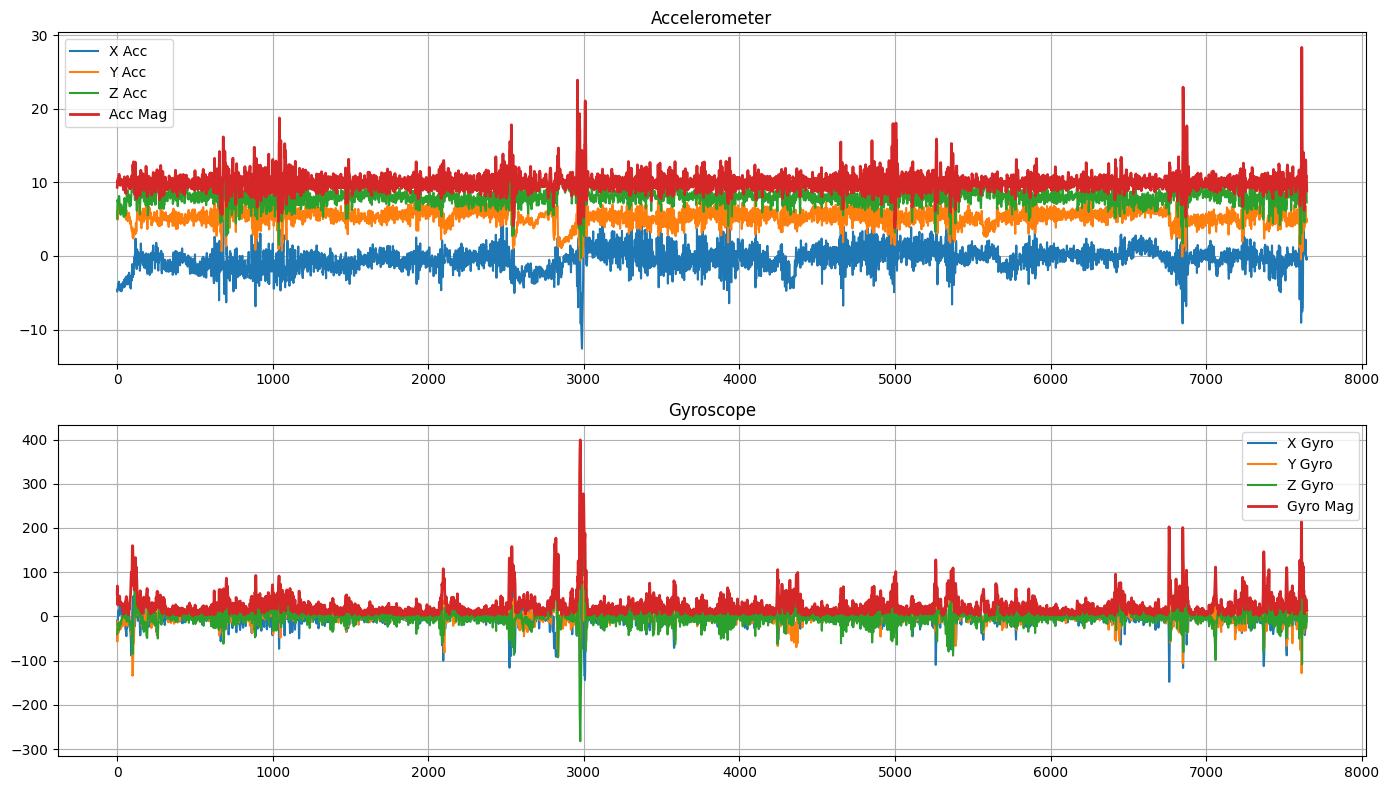

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualize_csv(file_path):
    df = pd.read_csv(file_path)

    # Add magnitude features
    df['Acc_Mag'] = np.sqrt(df['X_Acc']**2 + df['Y_Acc']**2 + df['Z_Acc']**2)
    df['Gyro_Mag'] = np.sqrt(df['X_Gyro']**2 + df['Y_Gyro']**2 + df['Z_Gyro']**2)

    plt.figure(figsize=(14, 8))

    # Accelerometer
    plt.subplot(2, 1, 1)
    plt.plot(df['X_Acc'], label='X Acc')
    plt.plot(df['Y_Acc'], label='Y Acc')
    plt.plot(df['Z_Acc'], label='Z Acc')
    plt.plot(df['Acc_Mag'], label='Acc Mag', linewidth=2)
    plt.title("Accelerometer")
    plt.legend()
    plt.grid()

    # Gyroscope
    plt.subplot(2, 1, 2)
    plt.plot(df['X_Gyro'], label='X Gyro')
    plt.plot(df['Y_Gyro'], label='Y Gyro')
    plt.plot(df['Z_Gyro'], label='Z Gyro')
    plt.plot(df['Gyro_Mag'], label='Gyro Mag', linewidth=2)
    plt.title("Gyroscope")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()
test_file = f"{DATASET_ROOT}/testing/vikram_5.1.csv"

if os.path.exists(test_file):

    # 🔹 Step 1: Visualize
    visualize_csv(test_file)
